<a href="https://colab.research.google.com/github/BenjiLSH/Statistical-modelling-of-extreme-values-Lab-Assignment/blob/main/BERN02_Ex3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Example of a Reproducible Workflow**

**Authors:** Sek Huen Leung, Kadri Kalamäe

**Date analysis last run:** 13.09.2026

## **How to Run This Workflow**

This notebook performs an extreme value analysis in R, using the `extRemes` package. It was developed and tested in Google Colab.

**Requirements:**

*   R runtime. In Google Colab: `Runtime > Change runtime type > R`.
*   The `extRemes` package (installed automatically by the first code cell below, pinned to a specific version).
*   No external data download is required: both datasets used (`PORTw` and `damage`) ship inside the `extRemes` package itself.

**To run:**

1.   Open this notebook in Google Colab (or any Jupyter environment with an R kernel).
2.   Run all cells top to bottom: `Runtime > Run all`.
3.   The first code cell installs the pinned version of `extRemes`.
4.   All figures and numerical results will regenerate. A `sessionInfo()` cell near the end records the exact R/package versions used for this run, for verification against the pinned versions.

In [1]:
# We pin extRemes to a specific CRAN version so that anyone re-running this notebook gets the exact same maximum likelihood estimates, p-values, and figures reported in the interpretive text below.
# See the markdown cell below for the motivation and a risk assessment.

if (!requireNamespace("remotes", quietly = TRUE)) {
  install.packages("remotes")
}
remotes::install_version("extRemes", version = "2.2-1", repos = "http://cran.r-project.org")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)




RcppArmad... (NA -> 15.6.0-1) [CRAN]
distillery   (NA -> 1.2-2   ) [CRAN]
Lmoments     (NA -> 1.3-2   ) [CRAN]


Installing 3 packages: RcppArmadillo, distillery, Lmoments

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



## **Why pin the version?**

CRAN packages are not guaranteed to be stable across releases: function signatures (e.g. `fevd()`, `ci()`, `threshrange.plot()`, `lr.test()`), default arguments etc. can change between versions of `extRemes`. Such a change could silently alter the maximum likelihood estimates, standard errors, p-values, or default plot output reported in this notebook (without raising an error). Pinning `extRemes` to the exact version used when this analysis was produced (via `remotes::install_version()`) guarantees that anyone re-running this notebook reproduces the identical results.

## **Risk assessment: what could break this workflow in the future?**

*   If `extRemes` were archived, the live CRAN mirror would no longer serve it, though `remotes::install_version()` can often still retrieve archived versions from CRAN's archive directory, and a mirrored copy could be vendored into this repository as a fallback.
*   This notebook uses base R graphics. Base graphics defaults may change across major R versions, which could alter figure appearance.
*   Google Colab's default R version and pre-installed system libraries could change, potentially breaking the install step itself.
*   `extRemes` itself depends on other CRAN packages. A breaking change in one of those, or one of them being archived, could make `extRemes` fail to install even with a pinned version number, since `remotes::install_version()` does not pin transitive dependencies by default.

## **Covariate inclusion in the block-maxima approach**

In this section, we are working with maximum winter temperature data for the time period 1927 to 1995 at Port Jervis, New York. We want to investigate whether the Arctic Oscillation (AO) index should be included as a covariate in a GEV model for temperature data. We load the $\texttt{PORTw}$ dataset directly from the $\texttt{extRemes}$ library using $\texttt{data("PORTw", package = "extRemes")}$, eliminating the need to fetch external data files.

In [2]:
library(extRemes)
data("PORTw", package = "extRemes")

Loading required package: Lmoments

Loading required package: distillery


Attaching package: ‘extRemes’


The following objects are masked from ‘package:stats’:

    qqnorm, qqplot




**Question 1** *The covariate is included in a linear transformation in the location parameters. What does it look like? What is the maximum likelihood estimators of the parameters in the linear transformation?*

First, we want to investigate whether the AO-index should be included as a covariate in a linear transformation in the location parameter $\mu$. Our model for $\mu$ can be written as
$$
    \mu(t) = \mu_0 + \mu_1 \text{AOindex}(t).
$$

In [3]:
fit1 <- fevd(TMX1, PORTw, units = "deg C")
fit2 <- fevd(TMX1, PORTw, location.fun = ~ AOindex, units = "deg C")
co <- ci(fit2, type = "parameter")
round(co, 3)

fevd(x = TMX1, data = PORTw, location.fun = ~AOindex, units = "deg C")

[1] "Normal Approx."

      95% lower CI Estimate 95% upper CI
mu0         14.556   15.254       15.951
mu1          0.529    1.152        1.775
scale        2.207    2.681        3.155
shape       -0.313   -0.181       -0.049




The maximum likelihood estimates of the parameters are $\hat{\mu}_0 = 15.254$ and $\hat{\mu}_1 = 1.152$. The intercept $\hat{\mu}_0 = 15.254^{\circ}\text{C}$ represents the location parameter when the AO-index is zero and the slope $\hat{\mu}_1 = 1.152^{\circ}\text{C}$ indicates that a one-unit increase in AO-index corresponds to an increase of approximately $1.15^{\circ}\text{C}$ in the location parameter.

**Question 2** *There are two plots, for mu0 and mu1. What do they correspond to?*

For diagnostics, we can use the function $\texttt{plot(fit2, "trace")}$. Its output can be seen in Figure 1. The first two columns correspond to $\mu_0$ and $\mu_1$.  

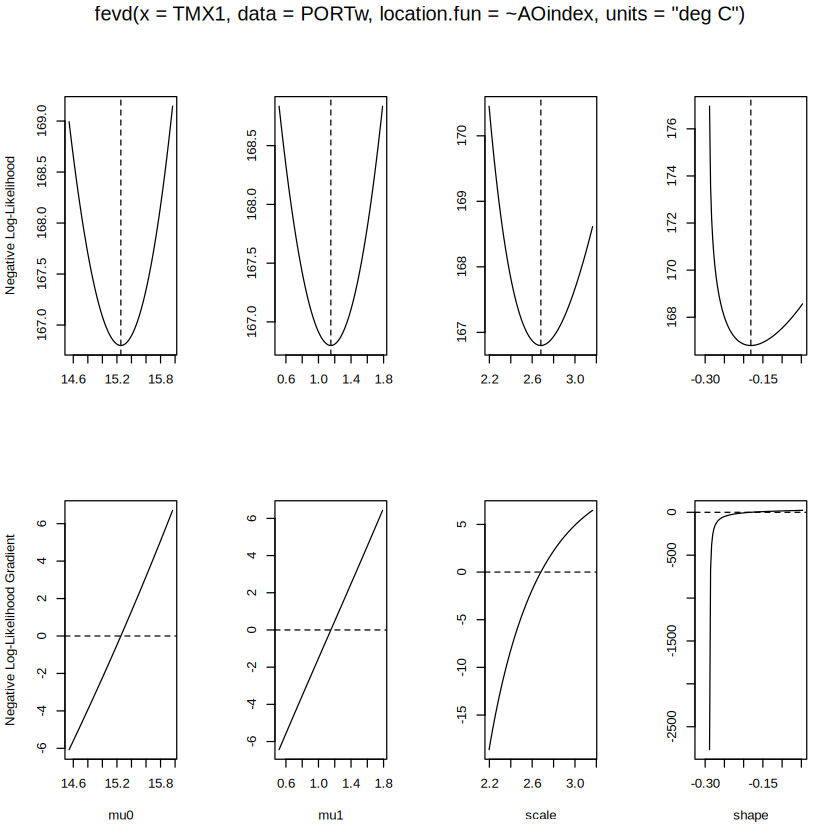

In [4]:
suppressWarnings(plot(fit2, "trace"))

*Figure 1: Likelihood traces with gradients for all four parameters in fit2.*

The upper row shows the negative log-likelihood as a function of each parameter while holding all other parameters fixed at their MLE values. For both $\mu_0$ and $\mu_1$, the curves are U-shaped and have a clear minimum, indicated by the dashed vertical line. The minimum for $\mu_0$ occurs at approximately $15.25$ and for $\mu_1$ at approximately $1.15$, which correspond exactly to the MLE estimates obtained from $\texttt{fit2}$.

The lower row shows the gradient of the negative log-likelihood with respect to each parameter. For both $\mu_0$ and $\mu_1$, the gradient is a near-perfectly straight line that crosses zero, indicated by the horizontal dashed line, at the parameter value corresponding to the MLE.

**Question 3** *What is the p-value in the likelihood-ratio test? What is your conclusion?*

To test whether the inclusion of the AO-index in the location parameter is statistically significant, we can use a likelihood ratio test with null hypothesis $H_0 : \mu_1 = 0$ with a test statistic
\begin{equation*}
    D = 2 \left(l(\hat{\theta}_{\texttt{fit2}}) - l(\hat{\theta}_{\texttt{fit1}})\right),
\end{equation*}
where $\hat{\theta}_{\texttt{fit2}}$ is the maximum likelihood estimate of the parameters with $\mu_1$ included and $\hat{\theta}_{\texttt{fit1}}$ is the maximum likelihood estimate of the parameters with $\mu_1 = 0$.

In [5]:

lr.test(fit1, fit2)


	Likelihood-ratio Test

data:  TMX1TMX1
Likelihood-ratio = 11.887, chi-square critical value = 3.8415, alpha =
0.0500, Degrees of Freedom = 1.0000, p-value = 0.0005653
alternative hypothesis: greater


The likelihood-ratio test gives a $p$-value of $0.00057$, which is far below the significance level of $\alpha = 0.05$. The test statistic is $11.887$, which exceeds the chi-square critical value of $3.842$ with $1$ degree of freedom. We therefore reject the null hypothesis that the simpler model without the AO-index covariate is sufficient and conclude that including the AO-index in the location parameter significantly improves the model fit.

**Question 4** *Explain the above in more detail. What are the return levels values for the covariate choices?*

In order to obtain return levels, when using a model with covariates, we must specify a covariate value as well as the (estimated) values of the GEV parameters. This is because when a covariate is included in the model, return levels depend not only on the return period but also on the value of the covariate. These are referred to as "effective return levels". In this example, we will study the AO-index values $-0.5$ and $0.5$.

In [6]:
AO.cov <- make.qcov(fit2, vals = list(mu1 = c(-0.5, 0.5)))
return.level(fit2, return.period = c(2, 20, 100), qcov = AO.cov)

fevd(x = TMX1, data = PORTw, location.fun = ~AOindex, units = "deg C")
return.level.ns.fevd.mle(x = x, return.period = return.period, 
    do.ci = FALSE, qcov = qcov, qcov.base = qcov.base)
[1] "GEV model fitted to TMX1 (deg C)"
Data are assumed to be  non-stationary 
[1] "Covariate data = PORTw"
[1] "Covariate data used for effective return levels here = qcov"
[1] "Return Levels for period units in years"
     2-year level 20-year level 100-year level
[1,]     15.62858      20.83516       23.04336
[2,]     16.78046      21.98704       24.19524

For $\text{AO-index} = -0.5$, the effective return levels are $15.63^{\circ}\text{C}$, $20.84^{\circ}\text{C}$, and $23.04^{\circ}\text{C}$ for the $2$-year, $20$-year, and $100$-year return periods respectively. For $\text{AO-index} = 0.5$, the corresponding return levels are $16.78^{\circ}\text{C}$, $21.99^{\circ}\text{C}$, and $24.20^{\circ}\text{C}$. The difference between the two scenarios (which differ by exactly $1$ unit of the AO-index) is approximately $1.15^{\circ}\text{C}$ across all return periods, which is consistent with the estimated slope $\hat{\mu}_1 = 1.152$. This can be explained by the way we estimate the return levels $\hat{z}_p$ using the GEV parameters. The estimator for $\hat{z}_p$ for $\xi \ne 0 $ is given by:
\begin{equation*}
     \hat{z}_p = \hat{\mu} - \frac{\hat{\sigma}}{\hat{\xi}}\left( 1-y_p^{-\hat{\xi}}\right),
\end{equation*}
where $y_p = -\log(1-p)$. Therefore, an increase of one unit in the AO-index corresponds to an addition of $\hat{\mu}_1$ to $\hat{\mu}$, which itself corresponds to an addition of $\hat{\mu}_1$ to the estimated return level $\hat{z}_p$.

**Question 5** *What are the p-values in the above tests? You may be helped by looking at the degrees of freedom in the two tests, and in the output of the analysis for fit2 and fit3. Which p-value corresponds to a test for inclusion of the AO index into the scale parameter? What is your conclusion about whether AO should be included into the scale parameter?*

Now, we would like to include the AO-index into another GEV parameter, e.g. the scale. For this, we run
$$
    \texttt{fit3 <- fevd(TMX1, PORTw, location.fun= \string~ AOindex, scale.fun = \string~ AOindex,
units = "deg C")}
$$
With that we have the nested sequence $\texttt{fit1} \subseteq \texttt{fit2} \subseteq \texttt{fit3}$ and when doing a likelihood ratio test for $\texttt{fit3}$, we can compare it to $\texttt{fit2}$ or to $\texttt{fit1}$.

In [7]:
fit3 <- fevd(TMX1, PORTw, location.fun= ~ AOindex, scale.fun = ~ AOindex,
             units = "deg C")
lr.test(fit1, fit3)


	Likelihood-ratio Test

data:  TMX1TMX1
Likelihood-ratio = 12.167, chi-square critical value = 5.9915, alpha =
0.0500, Degrees of Freedom = 2.0000, p-value = 0.00228
alternative hypothesis: greater


The likelihood ratio test of $\texttt{fit1}$ against $\texttt{fit3}$ gives a $p$-value of $0.00228$, which is significant at the $5$\% level. However, this test evaluates the joint significance of including AO-index in both the location and scale parameters simultaneously with $2$ degrees of freedom, so it does not isolate the effect of including it in the scale parameter alone.

In [8]:
lr.test(fit2, fit3)


	Likelihood-ratio Test

data:  TMX1TMX1
Likelihood-ratio = 0.27983, chi-square critical value = 3.8415, alpha =
0.0500, Degrees of Freedom = 1.0000, p-value = 0.5968
alternative hypothesis: greater


The relevant test for whether AO-index should be included in the scale parameter is the comparison of $\texttt{fit2}$ against $\texttt{fit3}$, since these two models differ only in whether AO-index appears in the scale parameter. This test gives a $p$-value of $0.597$, which is far above the $5$\% significance level, and the likelihood-ratio statistic of $0.280$ is much smaller than the chi-square critical value of $3.842$ with $1$ degree of freedom.
The conclusion is therefore that there is no statistical evidence that including AO-index in the scale parameter improves the model fit beyond what is already achieved by including it in the location parameter. Model $\texttt{fit2}$ is preferred.

## **The threshold excess method**

For this part, we will use hurricane damage data on estimated damages for US hurricanes from 1926 to 1995. Figure 2 shows the annual hurricane damages on both the original scale (left) and a logarithmic scale (right).

For choosing an appropriate threshold, we have studied two methods:

*   Choose different thresholds and plot a transformation of the scale (which should be constant if the GP distribution is valid) and from that plot choose a threshold.
*   Use the mean excess values and look for a linear fit.

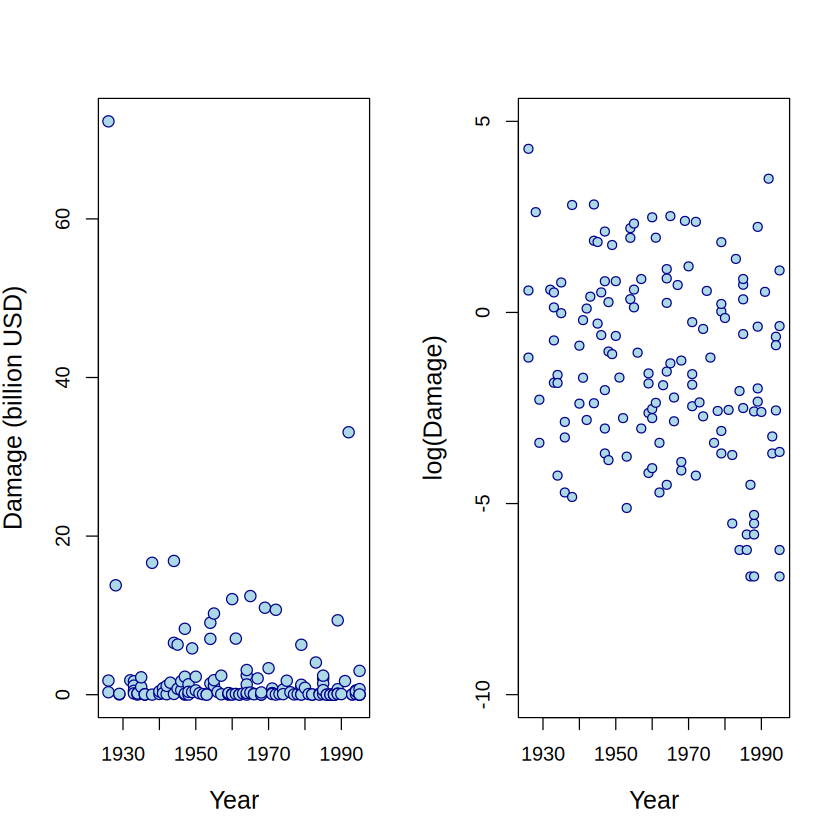

In [9]:
data("damage", package = "extRemes")
par(mfrow = c(1, 2))
plot(damage$Year, damage$Dam, xlab = "Year",
     ylab = "Damage (billion USD)", cex = 1.25,
     cex.lab = 1.25, col = "darkblue", bg = "lightblue", pch = 21)
plot(damage[, "Year"], log(damage[, "Dam"]), xlab = "Year",
     ylab = "log(Damage)", ylim = c(-10, 5), cex.lab = 1.25,
     col = "darkblue", bg = "lightblue", pch = 21)

*Figure 2:  Estimated US hurricane damages (1926-1995) plotted on the raw scale in billions of USD (left) and on a logarithmic scale (right).*

**Question 6** *One should choose a threshold u so that the parameter estimates will "not change much", taking into account the confidence interval bounds, as the threshold increases to more than u, while u remains low enough as to use as much data as possible. Give a (subjective, agreed!) choice of u.*

First, we will try the method that repeatedly fits a GP distribution for different threshold choices. Note that the scale parameter $\sigma(u)$ will depend on the threshold and is transformed into $\sigma^* = \sigma(u) - \xi u$, which, if the GP is a good fit, should not depend on $u$. The threshold selection plot below shows the reparameterized scale $\sigma^*$ and the shape parameter $\xi$ as functions of the threshold $u$, along with their confidence intervals.

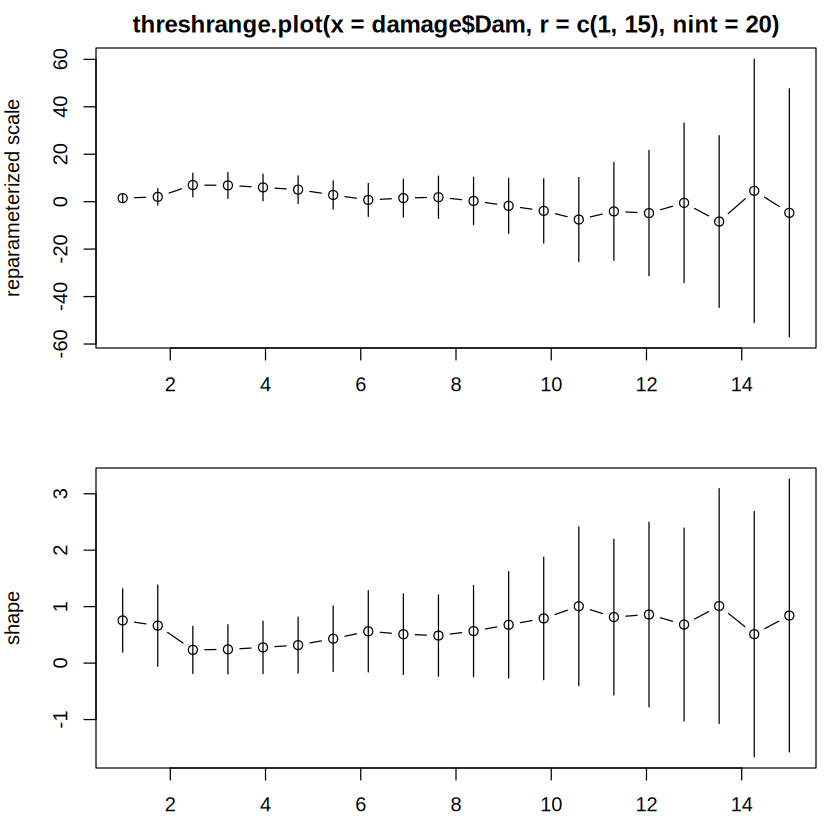

In [10]:
par(mfrow = c(1, 1))
old_mar <- par(mar = c(3, 4, 2, 1))
threshrange.plot(damage$Dam, r = c(1, 15), nint = 20)
par(mar = old_mar)

*Figure 3: Threshold selection diagnostic plot for the hurricane damage data. The top panel shows the reparameterized scale parameter $σ^*$ and the bottom panel shows the shape **parameter** $ξ$ across a range of thresholds $u \in [1,15]$ with 95% confidence intervals.*

For the reparameterized scale, the estimates are relatively stable from around $u = 4$ onwards. For the shape parameter, the estimates settle at around $0.3$ to $0.5$ from approximately $u = 3$ or $4$ onwards. The estimates for both parameters remain quite stable through to around $u = 10$ before the confidence intervals begin to widen due to fewer exceedances being available ($10$ exceedances for $u = 10$ compared to $20$ for $u = 4$). In our opinion, a reasonable choice of threshold is therefore $u = 4$ billion USD. At this point both parameter estimates have stabilized and enough data remains above the threshold to give reliable estimates.

**Question 7** *One should select a threshold such that the graph is linear to the right of that threshold, taking into account the confidence interval bounds, as the threshold increases. Give a (subjective, agreed!) choice of u.*

Now, alternatively, we try the method that uses mean excess values. The mean excess plot below shows the mean excess function against the threshold, with dashed lines indicating the confidence bounds. Note that if the GP distribution is a valid model for the exceedances above a threshold $u$, the mean excess function should be approximately linear to the right of that threshold.

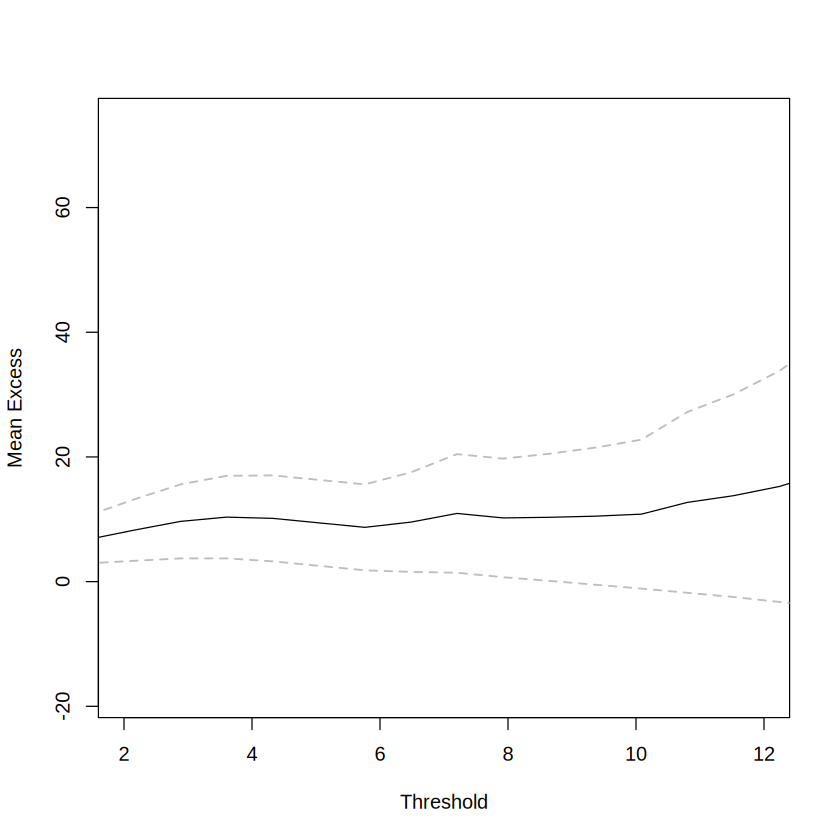

In [11]:
par(mfrow = c(1, 1))
mrlplot(damage$Dam, xlim = c(2, 12))

*Figure 4: Mean residual life plot for the US hurricane damage data across thresholds from $2$ to $12$ billion USD. The solid line represents the empirical mean excess, and the dashed lines indicate the $95$% confidence intervals.*

The plot shows a fairly linear trend in the mean excess function across most of the range shown, especially when taking the confidence intervals into account. We changed the aspect ratio of the plot to have a shorter $x$-axis, revealing that there seems to be a slight rise from $u=2$ to $u=4$, followed by a slight drop $u=4$ to $u=6$ from where onward the line seems to be more linear. Choosing a lower threshold such as $u = 2$ could be justified given that the linearity seems to hold from early on, but $u = 6$ seems to be a more conservative and safer choice based on the slight bump.

**Question 8** *What is the result of the analysis? Does the diagnostic q-q plot (the upper left plot, which shows outliers) indicate that the GP is not a good fit? Can you explain why it perhaps does not do that? State a 95 \% confidence interval for the shape in the GP distribution, using Gaussian approximation, and using the properties of the mle.*

Now we suppose that we have come to the threshold choice $u = 6$ billion USD. Note that we need to adjust the time scale since we are acting as if we have yearly maxima, but in fact the data contains several hurricanes per year. Recall that we are interested in the annual return level. We can use the average number of hurricanes per year as an adjustment and treat the time unit accordingly. Looking at the data, the number of years covered is $70$, the total number of damages is $144$, gives $144/70 = 2.06$ hurricanes per year on average. We fit a GP distribution to the data
using the threshold excess method, by
$$
    \texttt{fitD <- fevd(Dam, damage, threshold = 6, type = "GP", time.units = "2.06/year")}.
$$

In [12]:
fitD <- fevd(Dam, damage, threshold = 6, type = "GP", time.units = "2.06/year")
coD <- ci(fitD, type = "parameter")
round(coD, 3)

fevd(x = Dam, data = damage, threshold = 6, type = "GP", time.units = "2.06/year")

[1] "Normal Approx."

      95% lower CI Estimate 95% upper CI
scale        1.027    4.589        8.151
shape       -0.155    0.512        1.179


The GP distribution fitted to the hurricane damage data above the threshold of $6$ billion USD gives an estimated scale parameter of $4.589$ and a shape parameter of $0.512$, with standard errors of $1.817$ and $0.340$ respectively. We can construct an approximate $95$\% confidence interval for the shape parameter $\xi$ based on the asymptotic normality of the MLE:

$$
\xi \pm 1.96 \cdot \text{SE} = 0.512 \pm 1.96 \cdot 0.340 = (-0.154, 1.179).
$$

Figure 5 shows the diagnostics for $\texttt{fitD}$. Looking at the Q-Q plot (upper left), the points follow the diagonal line reasonably well for most of the data, but there is one clear outlier in the upper right that deviates substantially from the line. This single extreme observation pulls the empirical quantiles well above what the model predicts at the upper tail. However, this does not necessarily mean the GP is a poor fit because extreme outliers are not unexpected and with only $18$ observations above the threshold there is considerable uncertainty. The density plot (lower left) also shows a broadly reasonable agreement between the empirical and modeled distributions.

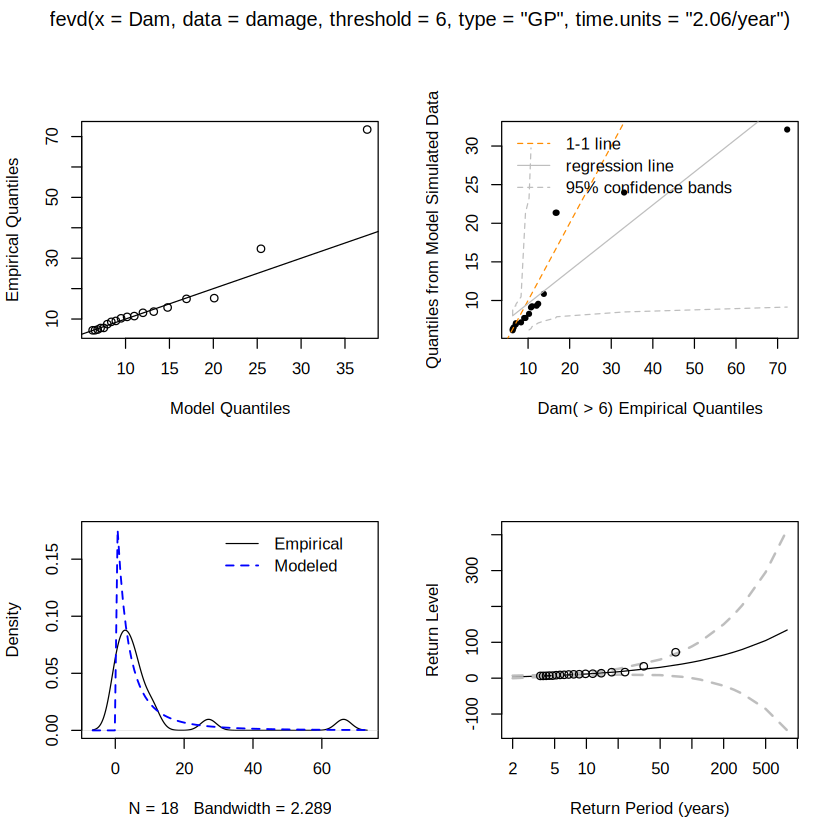

In [13]:
plot(fitD)

*Figure 5. Diagnostic plots for the GP distribution fitted to US hurricane damage data with threshold $u=6$.*

**Question 9** *As noted above the diagnostic plots, which will give return levels, will depend on the choice of time.units. The estimated parameter values will however not. You can test this by changing for instance "2.06/year" to "10/year" in the above code. Can you explain why the mle's of the parameters in the GP do not depend on the time scale?*

Let $u$ be the chosen threshold and $y_1,\dots,y_k$ our data of exceedances above that threshold. Then we know that the log-likelihood of the generalized Pareto distribution is given by
\begin{align*}
    l(\xi, \sigma_u) &= -k\log\sigma_u - \left(1+\frac{1}{\xi} \right) \sum_{i=1}^k \log\left(1+\frac{\xi y_i}{\sigma_u} \right) \quad \text{, if } \xi \ne 0 \\
    l(\sigma_u) &= -k\log\sigma_u - \frac{1}{\sigma_u} \sum_{i=1}^k y_i \quad \text{, if } \xi = 0.
\end{align*}
Thus the MLEs of the GP parameters do not depend on the time scale because the GP distribution is fitted only to the exceedances above the threshold, that is, to the values of the damage that exceed $6$ billion USD in our example. The time scale parameter controls how often we expect the threshold to be exceeded per year and this rate of occurrence is used when converting GP parameter estimates into return levels.

## **Reproducibility record**

The cell below records the exact R version and the versions of all attached/loaded packages at the time this notebook was last fully executed. Compare this against the pinned `extRemes` version above if you re-run this notebook and get different results.

In [14]:
sessionInfo()

R version 4.6.1 (2026-06-24)
Platform: x86_64-pc-linux-gnu
Running under: Ubuntu 24.04.4 LTS

Matrix products: default
BLAS:   /usr/lib/x86_64-linux-gnu/openblas-pthread/libblas.so.3 
LAPACK: /usr/lib/x86_64-linux-gnu/openblas-pthread/libopenblasp-r0.3.26.so;  LAPACK version 3.12.0

locale:
 [1] LC_CTYPE=en_US.UTF-8       LC_NUMERIC=C              
 [3] LC_TIME=en_US.UTF-8        LC_COLLATE=en_US.UTF-8    
 [5] LC_MONETARY=en_US.UTF-8    LC_MESSAGES=en_US.UTF-8   
 [7] LC_PAPER=en_US.UTF-8       LC_NAME=C                 
 [9] LC_ADDRESS=C               LC_TELEPHONE=C            
[11] LC_MEASUREMENT=en_US.UTF-8 LC_IDENTIFICATION=C       

time zone: Etc/UTC
tzcode source: system (glibc)

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
[1] extRemes_2.2-1   distillery_1.2-2 Lmoments_1.3-2  

loaded via a namespace (and not attached):
 [1] digest_0.6.39     IRdisplay_1.1     base64enc_0.1-6   fastmap_1.2.0    
 [5

# **Discussion of the FAIR Principles**

## **Findable**
This workflow is stored in a public GitHub repository with a descriptive name, a `README.md` summarizing the analysis and how to run it, and repository topics/keywords that make it discoverable via GitHub search. No persistent identifier (e.g. a Zenodo DOI) has been created for this coursework, but doing so would further improve findability.

## **Accessible**
The notebook is openly accessible: it can be opened directly in Google Colab or any Jupyter environment with an R kernel, with no login or special credentials required beyond a Google account for Colab itself. The two datasets analyzed here ship inside the `extRemes` package and are loaded with `data(...)`, so there is no separate data download, access request, or external link needed. Installing the pinned package is sufficient to access the data as well as the code.

## **Interoperable**
The workflow uses widely adopted, standard formats and tools: the Jupyter Notebook format, the R language, and a mainstream, actively used CRAN package (`extRemes`). The statistical models and equations are written in standard statistical notation in LaTeX.

## **Reusable**
The pinned dependencies, license and `sessionInfo()` allow someone to install exactly the same computational environment and verify or extend these results.
The notebook documents its methodological choices in detail so a future user can see why a choice wa made and adapt it if they apply this workflow to a different dataset. Still note that the analysis is tailored to the specific `PORTw` and `damage` example datasets, and a user wanting to plug in their own data would need to adjust variable names and threshold choices accordingly.